1. IMPORTS & CONFIGURATION

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import matplotlib.pyplot as plt
import seaborn as sns

# Style global des graphes
sns.set_style("whitegrid")

# Spark session
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Fraud Detection EDA") \
    .getOrCreate()

print(" Spark initialisé avec succès")

 Spark initialisé avec succès


2. CHARGEMENT DES DONNÉES

In [2]:
df = spark.read.csv(
    "C:\\fraud-telecom\\data\\PS_20174392719_1491204439457_log.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|           0.0|      0|             0|
|   1| PAYMENT| 1864.28|C1666544295|      21249.0|      19384.72|M2044282225|           0.0|           0.0|      0|             0|
|   1|TRANSFER|   181.0|C1305486145|        181.0|           0.0| C553264065|           0.0|           0.0|      1|             0|
|   1|CASH_OUT|   181.0| C840083671|        181.0|           0.0|  C38997010|       21182.0|           0.0|      1|             0|
|   1| PAYMENT|11668.14|C2048537720|      41554.0|      29885.86|M1230701703|      

     Dataset massif → Spark obligatoire
     Problème = classification binaire (isFraud)
     Données financières déséquilibrées

3. STRUCTURE DU DATASET

In [3]:
print("Shape:", (df.count(), len(df.columns)))
df.printSchema()

Shape: (6362620, 11)
root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- isFlaggedFraud: integer (nullable = true)



    Analyse
    +6M lignes → Big Data réel
    Variables financières complètes
    Cible : isFraud

4. VALEURS MANQUANTES

In [4]:
missing = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

missing.show()

+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|step|type|amount|nameOrig|oldbalanceOrg|newbalanceOrig|nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|   0|   0|     0|       0|            0|             0|       0|             0|             0|      0|             0|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+



    Aucune valeur manquante détectée → dataset propre

4.1.vérification des doublons

In [5]:
duplicates = df.count() - df.dropDuplicates().count()

print("Nombre de doublons détectés :", duplicates)

if duplicates == 0:
    print(" Aucun doublon trouvé dans le dataset")
else:
    print(" Des doublons existent dans le dataset")

Nombre de doublons détectés : 0
 Aucun doublon trouvé dans le dataset


4.2.Vérification des types de données

In [6]:
print(df.dtypes)

[('step', 'int'), ('type', 'string'), ('amount', 'double'), ('nameOrig', 'string'), ('oldbalanceOrg', 'double'), ('newbalanceOrig', 'double'), ('nameDest', 'string'), ('oldbalanceDest', 'double'), ('newbalanceDest', 'double'), ('isFraud', 'int'), ('isFlaggedFraud', 'int')]


5. STATISTIQUES DESCRIPTIVES

In [7]:
df.describe().show()

+-------+------------------+--------+------------------+-----------+------------------+-----------------+-----------+------------------+------------------+--------------------+--------------------+
|summary|              step|    type|            amount|   nameOrig|     oldbalanceOrg|   newbalanceOrig|   nameDest|    oldbalanceDest|    newbalanceDest|             isFraud|      isFlaggedFraud|
+-------+------------------+--------+------------------+-----------+------------------+-----------------+-----------+------------------+------------------+--------------------+--------------------+
|  count|           6362620| 6362620|           6362620|    6362620|           6362620|          6362620|    6362620|           6362620|           6362620|             6362620|             6362620|
|   mean|243.39724563151657|    NULL|179861.90354913048|       NULL| 833883.1040744851|855113.6685785787|       NULL|1100701.6665196505|1224996.3982019336|0.001290820448180152| 2.51468734577894E-6|
| stddev| 


    On observe que :
    Le dataset contient toujours 6 362 620 enregistrements complets (aucune valeur manquante détectée dans les colonnes analysées).
    La variable "amount" montre une forte dispersion (écart-type élevé), ce qui indique la présence de transactions de montants trèsvariés.
    Les soldes des comptes (oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest) présentent également une grande variabilité, ce qui est normal dans un système financier réel.
    La variable cible "isFraud" est très déséquilibrée avec une moyenne très faible (~0.0013), ce qui confirme que les fraudes sont rares.
    La présence de ce déséquilibre est un point critique pour le modèle de Machine Learning, nécessitant des techniques de rééquilibrage (SMOTE, undersampling ou pondération des classes).

5.1.ANALYSE DE LA VARIABLE CIBLE : isFraud

In [8]:
target_dist = df.groupBy("isFraud").count().orderBy("isFraud")

print("Distribution de la variable cible :")
target_dist.show()

Distribution de la variable cible :
+-------+-------+
|isFraud|  count|
+-------+-------+
|      0|6354407|
|      1|   8213|
+-------+-------+



In [9]:
fraud_pct = (8213 / (6354407 + 8213)) * 100
print(f"Taux de fraude : {fraud_pct:.4f}%")

Taux de fraude : 0.1291%


6. DISTRIBUTION DE LA CIBLE

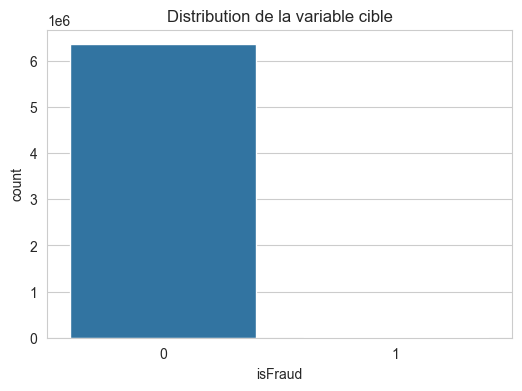

In [10]:
target_dist = df.groupBy("isFraud").count().toPandas()

plt.figure(figsize=(6,4))
sns.barplot(data=target_dist, x="isFraud", y="count")

plt.title("Distribution de la variable cible")
plt.show()

    Fraude ultra rare (~0.1%)
    Dataset fortement déséquilibré
    Accuracy inutile → utiliser Recall / F1

7. TYPES DE TRANSACTIONS vs FRAUDE

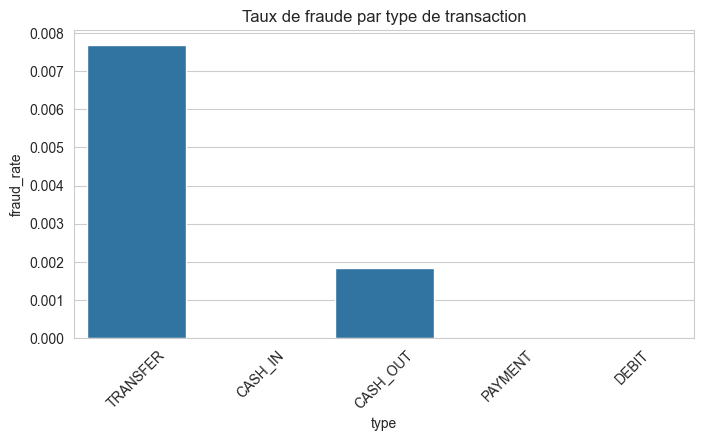

In [11]:
fraud_rate = df.groupBy("type").agg(
    F.avg("isFraud").alias("fraud_rate")
).toPandas()

plt.figure(figsize=(8,4))
sns.barplot(data=fraud_rate, x="type", y="fraud_rate")
plt.xticks(rotation=45)
plt.title("Taux de fraude par type de transaction")
plt.show()

    TRANSFER → plus risqué
    CASH_OUT → très fraudé
    PAYMENT / CASH_IN → quasi safe

8. ANALYSE DU MONTANT

+-------+------------------+
|summary|            amount|
+-------+------------------+
|  count|           6362620|
|   mean|179861.90354913048|
| stddev| 603858.2314629437|
|    min|               0.0|
|    max|     9.244551664E7|
+-------+------------------+



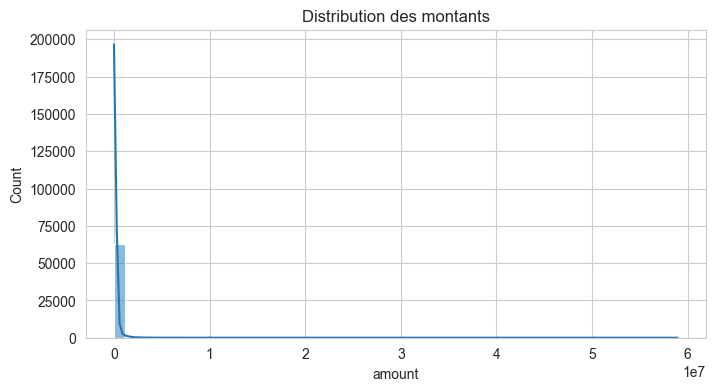

In [12]:
df.select("amount").describe().show()

sample_amount = df.select("amount").sample(0.01).toPandas()

plt.figure(figsize=(8,4))
sns.histplot(sample_amount["amount"], bins=50, kde=True)
plt.title("Distribution des montants")
plt.show()

        L'analyse de la variable amount montre une distribution fortement asymétrique à droite. La majorité des transactions concerne de faibles montants, tandis qu'un nombre limité de transactions présente des montants très élevés. Cette asymétrie se traduit par une longue queue à droite du graphique, révélant la présence de valeurs extrêmes (outliers). Ces observations sont importantes dans le contexte de la détection de fraude, car les transactions frauduleuses sont souvent associées à des montants inhabituels ou exceptionnellement élevés. Par conséquent, ces valeurs ont été conservées afin de préserver l'information pertinente pour l'apprentissage du modèle.
    

9. FEATURE ENGINEERING

In [13]:
df = df.withColumn(
    "balance_diff",
    F.col("oldbalanceOrg") - F.col("newbalanceOrig")
)

df = df.withColumn(
    "error_balance",
    F.col("oldbalanceOrg") - (F.col("newbalanceOrig") + F.col("amount"))
)

    Dans cette étape, nous créons de nouvelles variables à partir des données existantes afin d’améliorer la capacité du modèle à détecter les fraudes. 
    Deux nouvelles features sont ajoutées : 
    balance_diff : représente la différence entre le solde initial et le solde final de l’émetteur.
    error_balance : permet de détecter les incohérences entre le montant de la transaction et les variations de solde.
    Ces variables permettent de mieux capturer les comportements anormaux dans les transactions financières.

10. FRAUDE VS NORMAL (BOXPLOT)

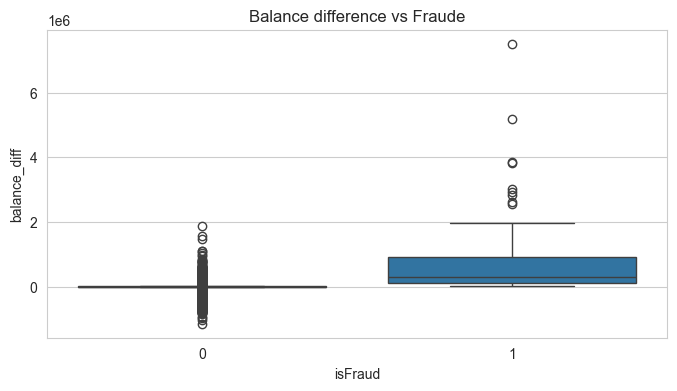

In [14]:
sample_df = df.select("isFraud", "balance_diff").sample(0.01).toPandas()

plt.figure(figsize=(8,4))
sns.boxplot(data=sample_df, x="isFraud", y="balance_diff")
plt.title("Balance difference vs Fraude")
plt.show()

    Fraudes → valeurs extrêmes
    Normal → distribution stable
    Feature très discriminante

11. CORRÉLATION

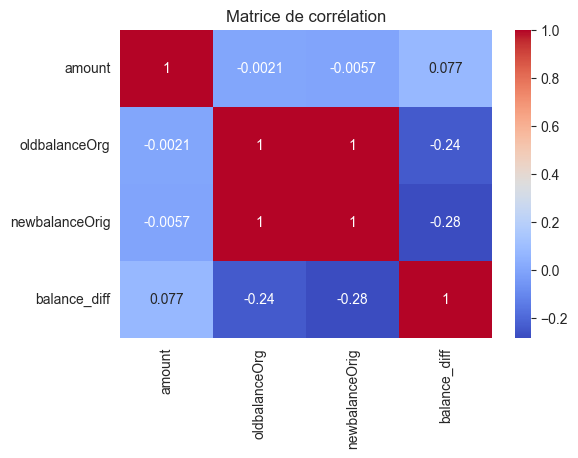

In [15]:
cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "balance_diff"]

corr_df = df.select(cols).sample(0.01).toPandas()

plt.figure(figsize=(6,4))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

    On observe plusieurs relations importantes : 
    oldbalanceOrg et newbalanceOrig sont fortement corrélées (~0.9988), ce qui indique qu’elles contiennent presque la même information.
    balance_diff est négativement corrélée avec oldbalanceOrg et newbalanceOrig, ce qui est logique car elle représente une différence.
    amount est faiblement corrélée avec les autres variables, ce qui indique qu’elle apporte une information complémentaire. 
    Ces résultats montrent qu’il existe une redondance entre certaines variables de solde, ce qui peut être pris en compte lors de la sélection des features.

12. FRAUDES PAR TYPE

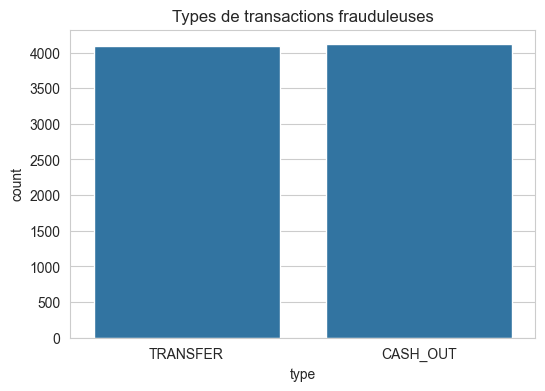

In [16]:
fraud_types = df.filter(df.isFraud == 1).groupBy("type").count().toPandas()

plt.figure(figsize=(6,4))
sns.barplot(data=fraud_types, x="type", y="count")
plt.title("Types de transactions frauduleuses")
plt.show()

13. COMPARAISON FRAUDE VS NORMAL

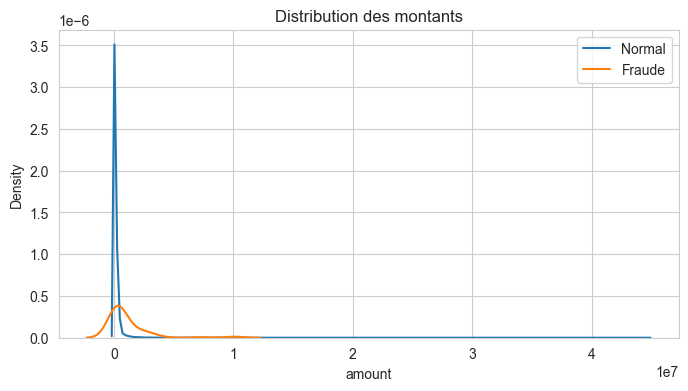

In [17]:
normal = df.filter(df.isFraud == 0).select("amount").sample(0.01).toPandas()
fraud = df.filter(df.isFraud == 1).select("amount").sample(0.01).toPandas()

plt.figure(figsize=(8,4))

sns.kdeplot(normal["amount"], label="Normal")
sns.kdeplot(fraud["amount"], label="Fraude")

plt.title("Distribution des montants")
plt.legend()
plt.show()

14. DATASET FINAL POUR ML

In [18]:
df_final = df.select(
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "balance_diff",
    "error_balance",
    "isFraud"
).sample(0.1).toPandas()

    CONCLUSION
    Dataset volumineux → Spark indispensable
    Dataset très déséquilibré (fraude rare)
    TRANSFER + CASH_OUT = zones à risque
    Features de balance = très discriminantes
    Presence de comportements incohérents dans fraude
    Nécessité de :

    SMOTE / undersampling
    modèles robustes (XGBoost / RandomForest)
    métriques : Recall + F1-score